# Chapter 1: Exploratory Data Analysis (EDA)

## 1. Summary / Ringkasan Bab
Exploratory Data Analysis (EDA) adalah langkah awal penting dalam ilmu data untuk memahami karakteristik dasar data sebelum menerapkan model machine learning. Bab ini berfokus pada teknik statistik deskriptif untuk mengukur pemusatan data (estimates of location), variabilitas (estimates of variability), distribusi data, serta hubungan antar variabel numerik maupun kategorik.

## 2. Theoretical Deep-Dive
- **Estimates of Location**:
  - *Mean (Rata-rata)*: Jumlah nilai dibagi banyaknya data. Rentan terhadap outlier.
  - *Trimmed Mean*: Rata-rata yang dihitung setelah membuang persentase tertentu dari nilai ekstrim.
  - *Median*: Nilai tengah data yang telah diurutkan. Lebih tahan terhadap outlier (robust).
- **Estimates of Variability**:
  - *Standard Deviation*: Ukuran penyebaran data relatif terhadap rata-rata.
  - *Interquartile Range (IQR)*: Selisih antara kuartil ke-3 ($Q_3$) dan kuartil ke-1 ($Q_1$).
  - *Median Absolute Deviation (MAD)*: Deviasi mutlak dari median, sangat tahan terhadap outlier.
- **Data Distribution & Correlation**:
  - *Percentiles/Boxplots*: Visualisasi ringkasan 5 angka (minimum, $Q_1$, median, $Q_3$, maksimum).
  - *Correlation Matrix/Scatterplot*: Mengukur keterikatan linier antar dua variabel numerik.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Membuat dataset dummy untuk simulasi data populasi & pendapatan
np.random.seed(42)
data = pd.DataFrame({
    'State': [f'State_{i}' for i in range(1, 51)],
    'Population': np.random.randint(100000, 10000000, size=50),
    'Murder_Rate': np.round(np.random.uniform(1.0, 10.0, size=50), 1),
    'Income': np.random.normal(50000, 15000, size=50)
})

# Menambahkan outlier pada Income untuk pengujian robust statistics
data.loc[0, 'Income'] = 500000

print("5 Data Pertama:")
data.head()

5 Data Pertama:


,State,Population,Murder_Rate,Income
0,State_1,6523388,3.8,500000.000000
1,State_2,6650634,5.7,62328.537566
2,State_3,4404572,5.9,51305.706024
3,State_4,2334489,2.7,45514.889743
4,State_5,9624682,9.7,51376.411648


In [3]:
# 1. Estimates of Location
mean_pop = data['Population'].mean()
trimmed_mean_pop = stats.trim_mean(data['Population'], proportiontocut=0.1)
median_pop = data['Population'].median()

print("=== ESTIMATES OF LOCATION (Population) ===")
print(f"Mean            : {mean_pop:,.2f}")
print(f"Trimmed Mean 10%: {trimmed_mean_pop:,.2f}")
print(f"Median          : {median_pop:,.2f}\n")

# 2. Estimates of Variability
std_dev = data['Income'].std()
iqr = stats.iqr(data['Income'])
mad = stats.median_abs_deviation(data['Income'])

print("=== ESTIMATES OF VARIABILITY (Income) ===")
print(f"Standard Deviation : {std_dev:,.2f}")
print(f"IQR                : {iqr:,.2f}")
print(f"MAD                : {mad:,.2f}")

=== ESTIMATES OF LOCATION (Population) ===
Mean            : 5,018,326.62
Trimmed Mean 10%: 4,960,209.25
Median          : 4,722,504.00

=== ESTIMATES OF VARIABILITY (Income) ===
Standard Deviation : 65,076.64
IQR                : 13,106.93
MAD                : 6,793.56


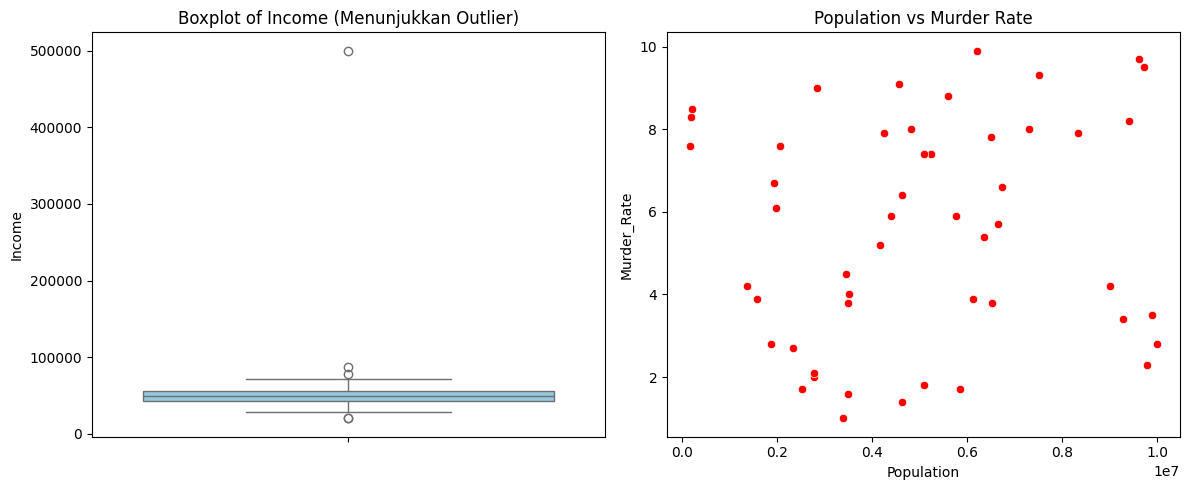

=== CORRELATION MATRIX ===
             Population  Murder_Rate    Income
Population     1.000000     0.101541  0.057637
Murder_Rate    0.101541     1.000000 -0.101435
Income         0.057637    -0.101435  1.000000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Boxplot
sns.boxplot(y=data['Income'], ax=axes[0], color='skyblue')
axes[0].set_title('Boxplot of Income (Menunjukkan Outlier)')

# Scatter plot
sns.scatterplot(x='Population', y='Murder_Rate', data=data, ax=axes[1], color='red')
axes[1].set_title('Population vs Murder Rate')

plt.tight_layout()
plt.show()

# Korelasi
print("=== CORRELATION MATRIX ===")
print(data[['Population', 'Murder_Rate', 'Income']].corr())